# 🩺 Deployment Filter Tuning, Clinical Benchmark & C Porting (PPG & ECG @ 100 Hz)

This notebook contains the complete tuning, frequency response analysis, clinical dataset benchmarking, and **ANSI C firmware export** for both **PPG** and **ECG** signals operating on a synchronized **$100.0\text{ Hz}$ timebase**.

---

## 📑 Table of Contents
1. [**SECTION 1: PPG Preprocessing & Pulse Morphology Tuning**](#section-1-ppg-preprocessing--pulse-morphology-tuning-100-hz)
   - [Step 1: Load Filter Configuration & Sensor Stream (`spo2_log.csv`)](#step-1-load-filter-configuration-configfilter_configjson--deployment-data-spo2_logcsv)
   - [Step 2: 4th-Order Chebyshev Type II Bode Frequency Response](#step-2-ppg-4th-order-chebyshev-type-ii-bode-response)
   - [Step 3: Chebyshev II BandPass ($0.2 - 10.0\text{ Hz}$) & Min-Max Normalization](#step-3-apply-chebyshev-ii-bandpass--min-max-normalization-to-spo2_logcsv)
   - [Step 4: Pulse Morphology Benchmark against `Filtered_Data/001_1.csv`](#step-4-pulse-morphology-benchmark-against-filtered_data001_1csv)
2. [**SECTION 2: Raw ECG Preprocessing, QRS Detection & Comparison**](#section-2-raw-ecg-filter-tuning--100-hz-anti-aliased-resampling)
   - [Step 5: Load Raw ECG (`Raw_data/001_1.csv`) & Anti-Aliased Resampling ($250\text{ Hz} \rightarrow 100\text{ Hz}$)](#step-5-load-raw-ecg-from-raw_data001_1csv--anti-aliased-resampling-250text-hz-rightarrow-100text-hz)
   - [Step 6: 3rd-Order Butterworth BandPass ($0.5 - 35.0\text{ Hz}$) Bode Response @ $100\text{ Hz}$](#step-6-ecg-filter-design--bode-response-3rd-order-05---350-hz-bandpass--100text-hz)
   - [Step 7: Pan-Tompkins QRS Energy Integration & Progression Plot](#step-7-apply-ecg-filter--pan-tompkins-qrs-detection--progression-plot--100-hz)
   - [Step 8: Dedicated ECG Comparison: Raw + Our Filter vs. Clinical Filtered Dataset](#step-8-dedicated-ecg-comparison-raw--our-filter-vs-clinical-filtered-dataset)
   - [Step 9: ECG Power Spectral Density (PSD) Verification @ $100\text{ Hz}$](#step-9-ecg-power-spectral-density-psd-verification--100text-hz)
3. [**SECTION 3: Production ANSI C Firmware Export (PPG & ECG)**](#section-3-production-c-firmware-export--verification-ppg--ecg--100-hz)
   - [Step 10: Export C Headers (`ppg_bandpass_filter.h`, `ecg_filter.h`) & Engines with Native GCC Verification](#step-10-export-embedded-c-headers--c-engines-for-ppg-and-ecg-preprocessing--100-hz)


In [1]:
import os
import sys
import json
import glob
import ctypes
import subprocess
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Robust absolute project root resolution
root_dir = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(root_dir, "config", "filter_config.json")):
    parent = os.path.dirname(root_dir)
    if parent == root_dir:
        break
    root_dir = parent

config_dir = os.path.join(root_dir, "config")
plots_dir = os.path.join(root_dir, "plots")
deploy_dir = os.path.join(root_dir, "deploy")
data_dir = os.path.join(root_dir, "A dataset of simultaneous collected ECG and PPG signals")

os.makedirs(config_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(deploy_dir, exist_ok=True)

print(f"Environment configured. Project Root: {root_dir}")


Environment configured. Project Root: /home/apt2736/PKM_BP


# ==============================================================================
# SECTION 1: PPG PREPROCESSING & PULSE MORPHOLOGY TUNING (@ 100 Hz)
# ==============================================================================


## Step 1: Load Filter Configuration (`config/filter_config.json`) & Deployment Data (`spo2_log.csv`)


In [2]:
cfg_path = os.path.join(config_dir, "filter_config.json")
with open(cfg_path, 'r') as f:
    filter_config = json.load(f)

ppg_cfg = filter_config['ppg_preprocessing']
ppg_filter_type = ppg_cfg['bandpass_filter'].get('filter_type', 'chebyshev2')
ppg_lowcut = float(ppg_cfg['bandpass_filter']['lowcut_hz'])
ppg_highcut = float(ppg_cfg['bandpass_filter']['highcut_hz'])
ppg_bp_order = int(ppg_cfg['bandpass_filter']['order'])
ppg_stopband_atten_db = float(ppg_cfg['bandpass_filter'].get('stopband_attenuation_db', 30.0))
ppg_zero_phase = bool(ppg_cfg['bandpass_filter']['zero_phase'])

print("--- Loaded PPG Preprocessing Parameters from config/filter_config.json ---")
print(f"  Filter Type          : {ppg_filter_type.upper()} Order {ppg_bp_order}")
print(f"  Passband Frequencies : [{ppg_lowcut} Hz, {ppg_highcut} Hz]")
print(f"  Stopband Attenuation : {ppg_stopband_atten_db} dB")
print(f"  Zero-Phase Enabled   : {ppg_zero_phase}")

csv_path = os.path.join(root_dir, "spo2_log.csv")
df_spo2 = pd.read_csv(csv_path, sep=';')
ir_raw = df_spo2['mon_ppg_ir_smooth'].values
red_raw = df_spo2['mon_ppg_red_smooth'].values
t_ir_ms = df_spo2['timestamp_mon_ppg_ir_smooth'].values
time_sec = (t_ir_ms - t_ir_ms[0]) / 1000.0
fs_spo2 = 1.0 / np.median(np.diff(time_sec))

print(f"\n--- Loaded Deployment Sensor Stream (spo2_log.csv) ---")
print(f"  Total Data Samples : {len(df_spo2):,} points ({time_sec[-1]:.2f} seconds at {fs_spo2:.1f} Hz)")
print(f"  PPG IR Raw Range   : [{ir_raw.min():.1f}, {ir_raw.max():.1f}] ADC counts")
print(f"  PPG Red Raw Range  : [{red_raw.min():.1f}, {red_raw.max():.1f}] ADC counts")


--- Loaded PPG Preprocessing Parameters from config/filter_config.json ---
  Filter Type          : CHEBYSHEV2 Order 4
  Passband Frequencies : [0.2 Hz, 10.0 Hz]
  Stopband Attenuation : 30.0 dB
  Zero-Phase Enabled   : True

--- Loaded Deployment Sensor Stream (spo2_log.csv) ---
  Total Data Samples : 5,045 points (50.44 seconds at 100.0 Hz)
  PPG IR Raw Range   : [191890.5, 197860.0] ADC counts
  PPG Red Raw Range  : [161264.8, 168186.3] ADC counts


## Step 2: PPG 4th-Order Chebyshev Type II Bode Response


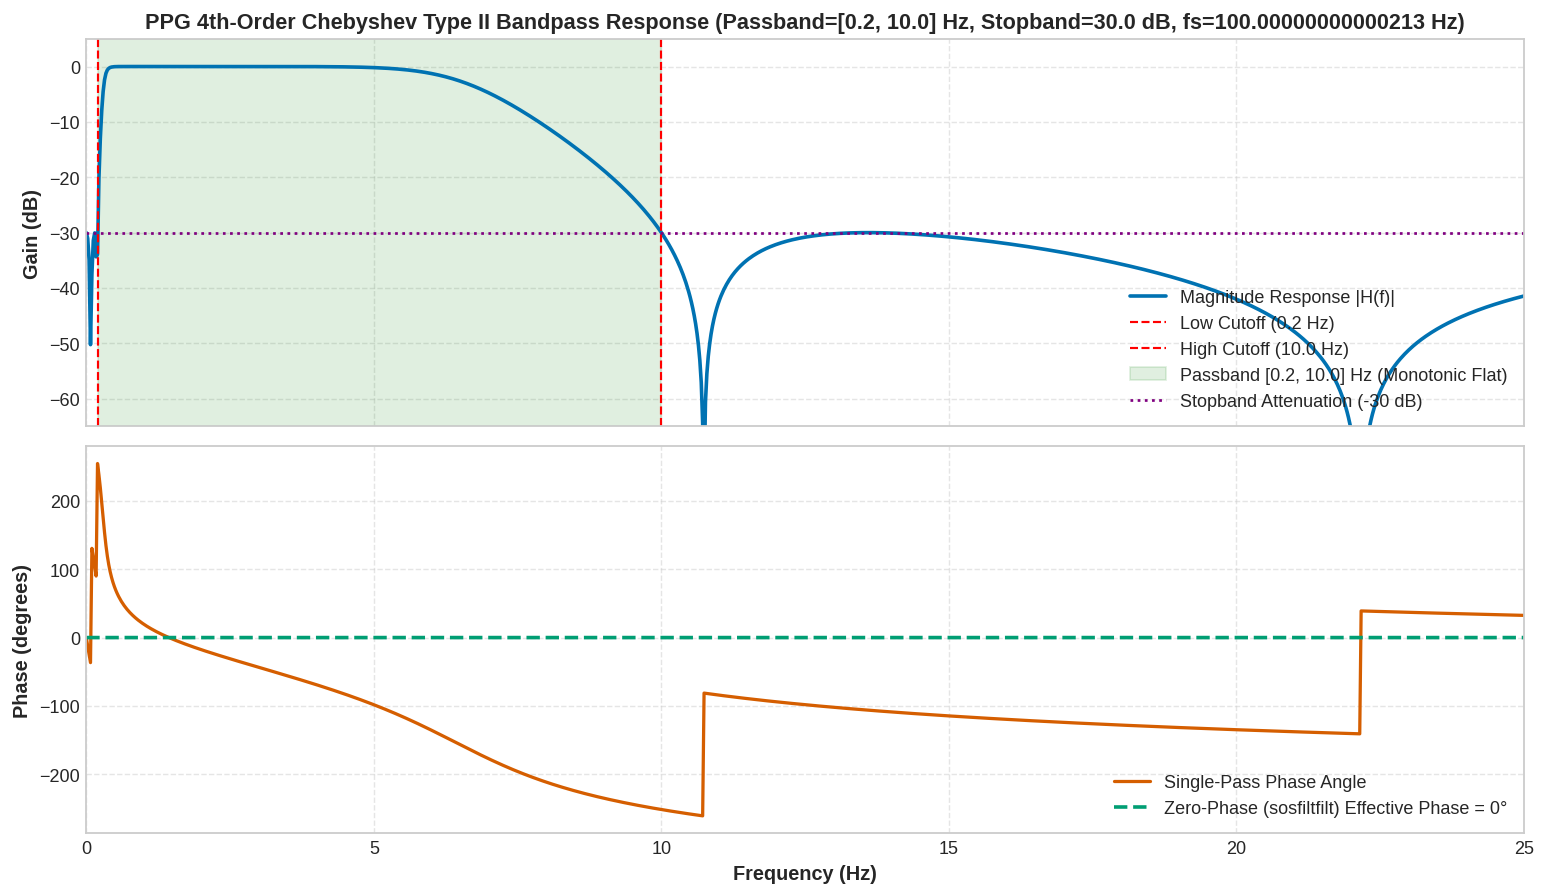

In [3]:
# Design Chebyshev Type II BandPass Filter (SOS)
sos_ppg = signal.cheby2(ppg_bp_order, ppg_stopband_atten_db, [ppg_lowcut, ppg_highcut], btype='bandpass', fs=fs_spo2, output='sos')
w_ppg, h_ppg = signal.sosfreqz(sos_ppg, worN=2048, fs=fs_spo2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# 1. Magnitude Response
ax1.plot(w_ppg, 20 * np.log10(np.maximum(np.abs(h_ppg), 1e-6)), color='#0072B2', linewidth=2.0, label='Magnitude Response |H(f)|')
ax1.axvline(ppg_lowcut, color='red', linestyle='--', linewidth=1.2, label=f'Low Cutoff ({ppg_lowcut} Hz)')
ax1.axvline(ppg_highcut, color='red', linestyle='--', linewidth=1.2, label=f'High Cutoff ({ppg_highcut} Hz)')
ax1.axvspan(ppg_lowcut, ppg_highcut, color='green', alpha=0.12, label=f'Passband [{ppg_lowcut}, {ppg_highcut}] Hz (Monotonic Flat)')
ax1.axhline(-ppg_stopband_atten_db, color='purple', linestyle=':', label=f'Stopband Attenuation (-{ppg_stopband_atten_db:.0f} dB)')
ax1.set_xlim(0, 25)
ax1.set_ylim(-65, 5)
ax1.set_ylabel("Gain (dB)", fontweight='bold')
ax1.set_title(f"PPG 4th-Order Chebyshev Type II Bandpass Response (Passband=[{ppg_lowcut}, {ppg_highcut}] Hz, Stopband={ppg_stopband_atten_db} dB, fs={fs_spo2} Hz)", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right')

# 2. Phase Response
angles_ppg = np.unwrap(np.angle(h_ppg)) * 180 / np.pi
ax2.plot(w_ppg, angles_ppg, color='#D55E00', linewidth=1.8, label='Single-Pass Phase Angle')
if ppg_zero_phase:
    ax2.plot(w_ppg, np.zeros_like(w_ppg), color='#009E73', linestyle='--', linewidth=2.0, label='Zero-Phase (sosfiltfilt) Effective Phase = 0°')
ax2.set_xlabel("Frequency (Hz)", fontweight='bold')
ax2.set_ylabel("Phase (degrees)", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "spo2_filter_bode_response.png"), dpi=300, bbox_inches='tight')
plt.show()


## Step 3: Apply Chebyshev II BandPass & Min-Max Normalization to `spo2_log.csv`


4th-Order Chebyshev II Preprocessing Executed Successfully on spo2_log.csv:
  IR  -> Raw: [191890.5, 197860.0] | BP AC: [-1687.1, 2460.4] | MinMax: [0.0000, 1.0000]
  Red -> Raw: [161264.8, 168186.3] | BP AC: [-572.6, 1010.9] | MinMax: [0.0000, 1.0000]


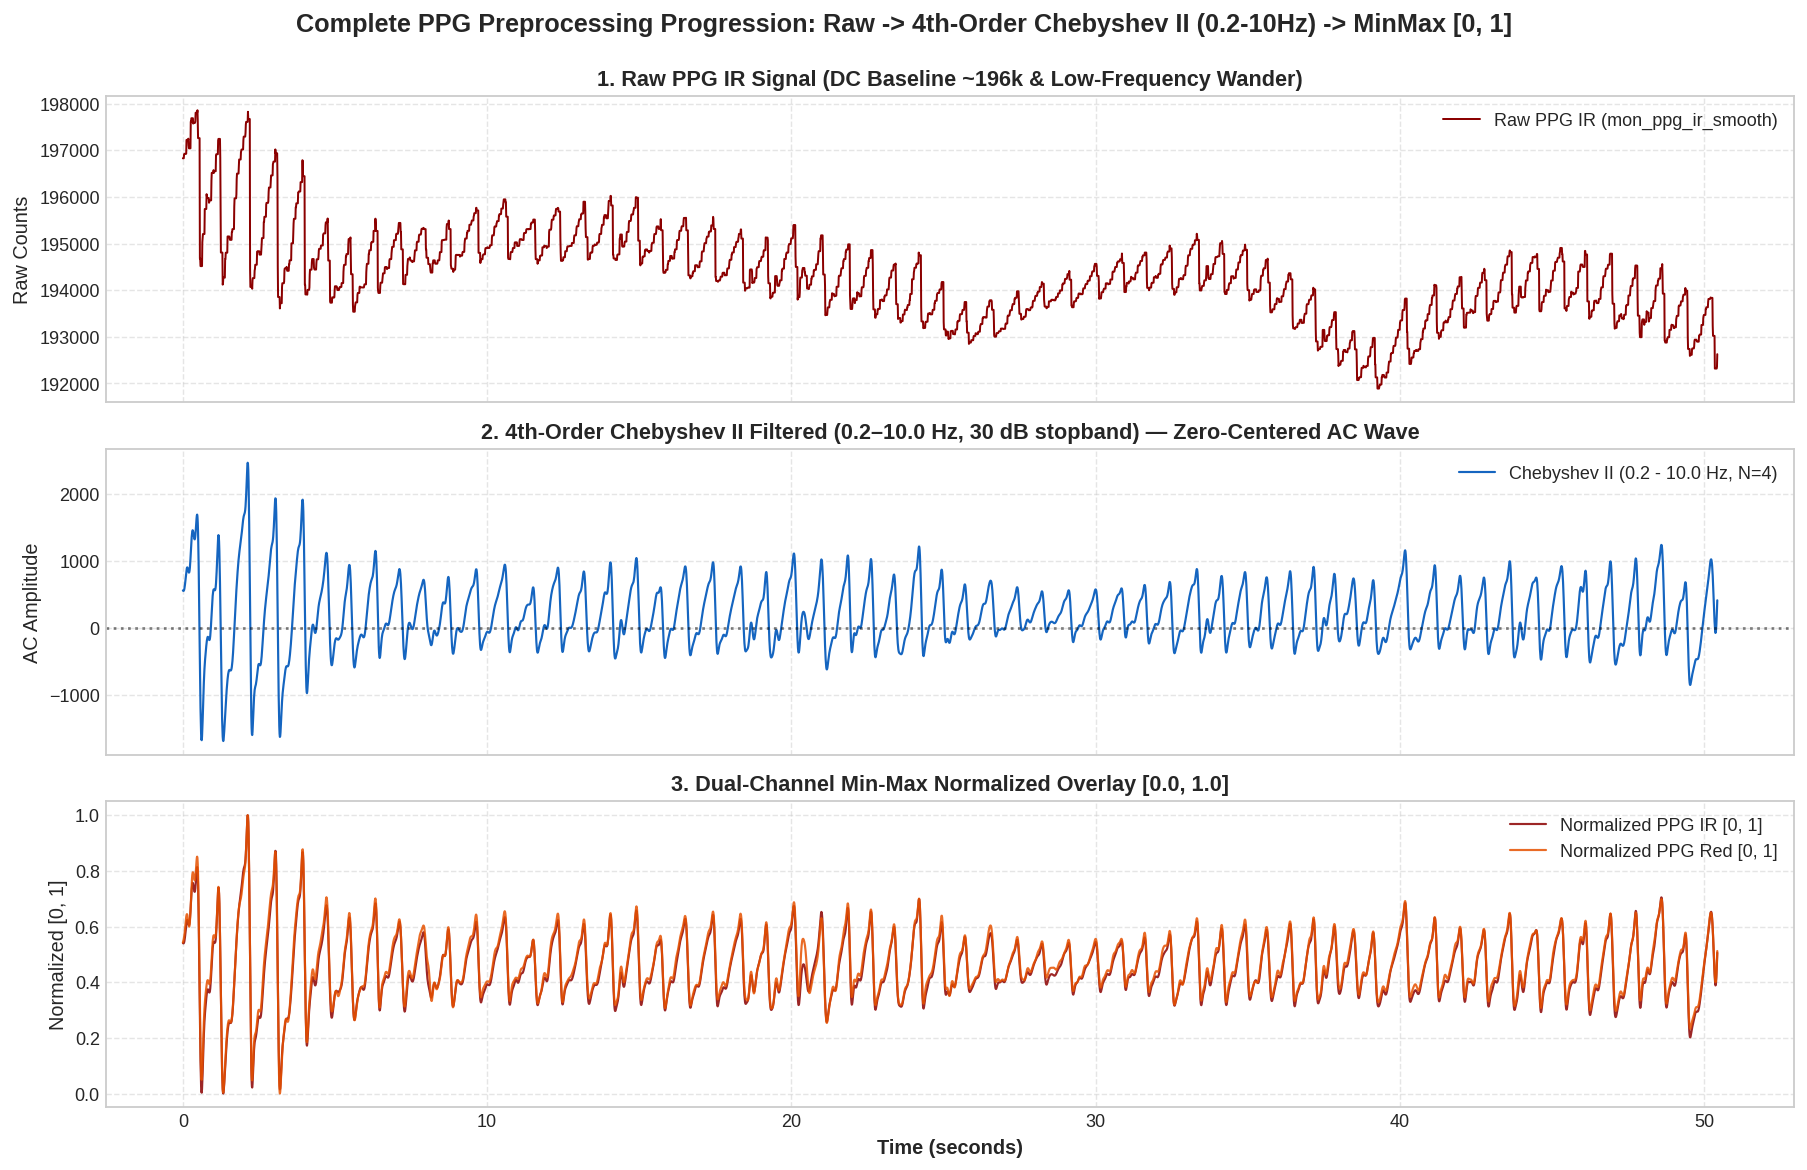

In [4]:
ir_bp = signal.sosfiltfilt(sos_ppg, ir_raw) if ppg_zero_phase else signal.sosfilt(sos_ppg, ir_raw)
red_bp = signal.sosfiltfilt(sos_ppg, red_raw) if ppg_zero_phase else signal.sosfilt(sos_ppg, red_raw)

ir_norm = (ir_bp - np.min(ir_bp)) / (np.max(ir_bp) - np.min(ir_bp) + 1e-5)
red_norm = (red_bp - np.min(red_bp)) / (np.max(red_bp) - np.min(red_bp) + 1e-5)

print("4th-Order Chebyshev II Preprocessing Executed Successfully on spo2_log.csv:")
print(f"  IR  -> Raw: [{ir_raw.min():.1f}, {ir_raw.max():.1f}] | BP AC: [{ir_bp.min():.1f}, {ir_bp.max():.1f}] | MinMax: [{ir_norm.min():.4f}, {ir_norm.max():.4f}]")
print(f"  Red -> Raw: [{red_raw.min():.1f}, {red_raw.max():.1f}] | BP AC: [{red_bp.min():.1f}, {red_bp.max():.1f}] | MinMax: [{red_norm.min():.4f}, {red_norm.max():.4f}]")

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1. Raw IR
axes[0].plot(time_sec, ir_raw, color='#8B0000', linewidth=1.1, label='Raw PPG IR (mon_ppg_ir_smooth)')
axes[0].set_title("1. Raw PPG IR Signal (DC Baseline ~196k & Low-Frequency Wander)", fontweight='bold')
axes[0].set_ylabel("Raw Counts")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right')

# 2. Chebyshev II Filtered IR
axes[1].plot(time_sec, ir_bp, color='#1565C0', linewidth=1.2, label=f'Chebyshev II ({ppg_lowcut} - {ppg_highcut} Hz, N={ppg_bp_order})')
axes[1].axhline(0, color='k', linestyle=':', alpha=0.5)
axes[1].set_title(f"2. 4th-Order Chebyshev II Filtered ({ppg_lowcut}–{ppg_highcut} Hz, 30 dB stopband) — Zero-Centered AC Wave", fontweight='bold')
axes[1].set_ylabel("AC Amplitude")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

# 3. Min-Max Normalized IR & Red Overlay
axes[2].plot(time_sec, ir_norm, color='#8B0000', alpha=0.85, linewidth=1.2, label='Normalized PPG IR [0, 1]')
axes[2].plot(time_sec, red_norm, color='#E65100', alpha=0.85, linewidth=1.2, label='Normalized PPG Red [0, 1]')
axes[2].set_title("3. Dual-Channel Min-Max Normalized Overlay [0.0, 1.0]", fontweight='bold')
axes[2].set_xlabel("Time (seconds)", fontweight='bold')
axes[2].set_ylabel("Normalized [0, 1]")
axes[2].set_ylim(-0.05, 1.05)
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right')

plt.suptitle("Complete PPG Preprocessing Progression: Raw -> 4th-Order Chebyshev II (0.2-10Hz) -> MinMax [0, 1]", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "spo2_bandpass_filtered_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()


## Step 4: Pulse Morphology Benchmark against `Filtered_Data/001_1.csv`


/tmp/ipykernel_2270330/12132301.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved PPG pulse morphology comparison plot to: /home/apt2736/PKM_BP/plots/spo2_pulse_morphology_comparison.png


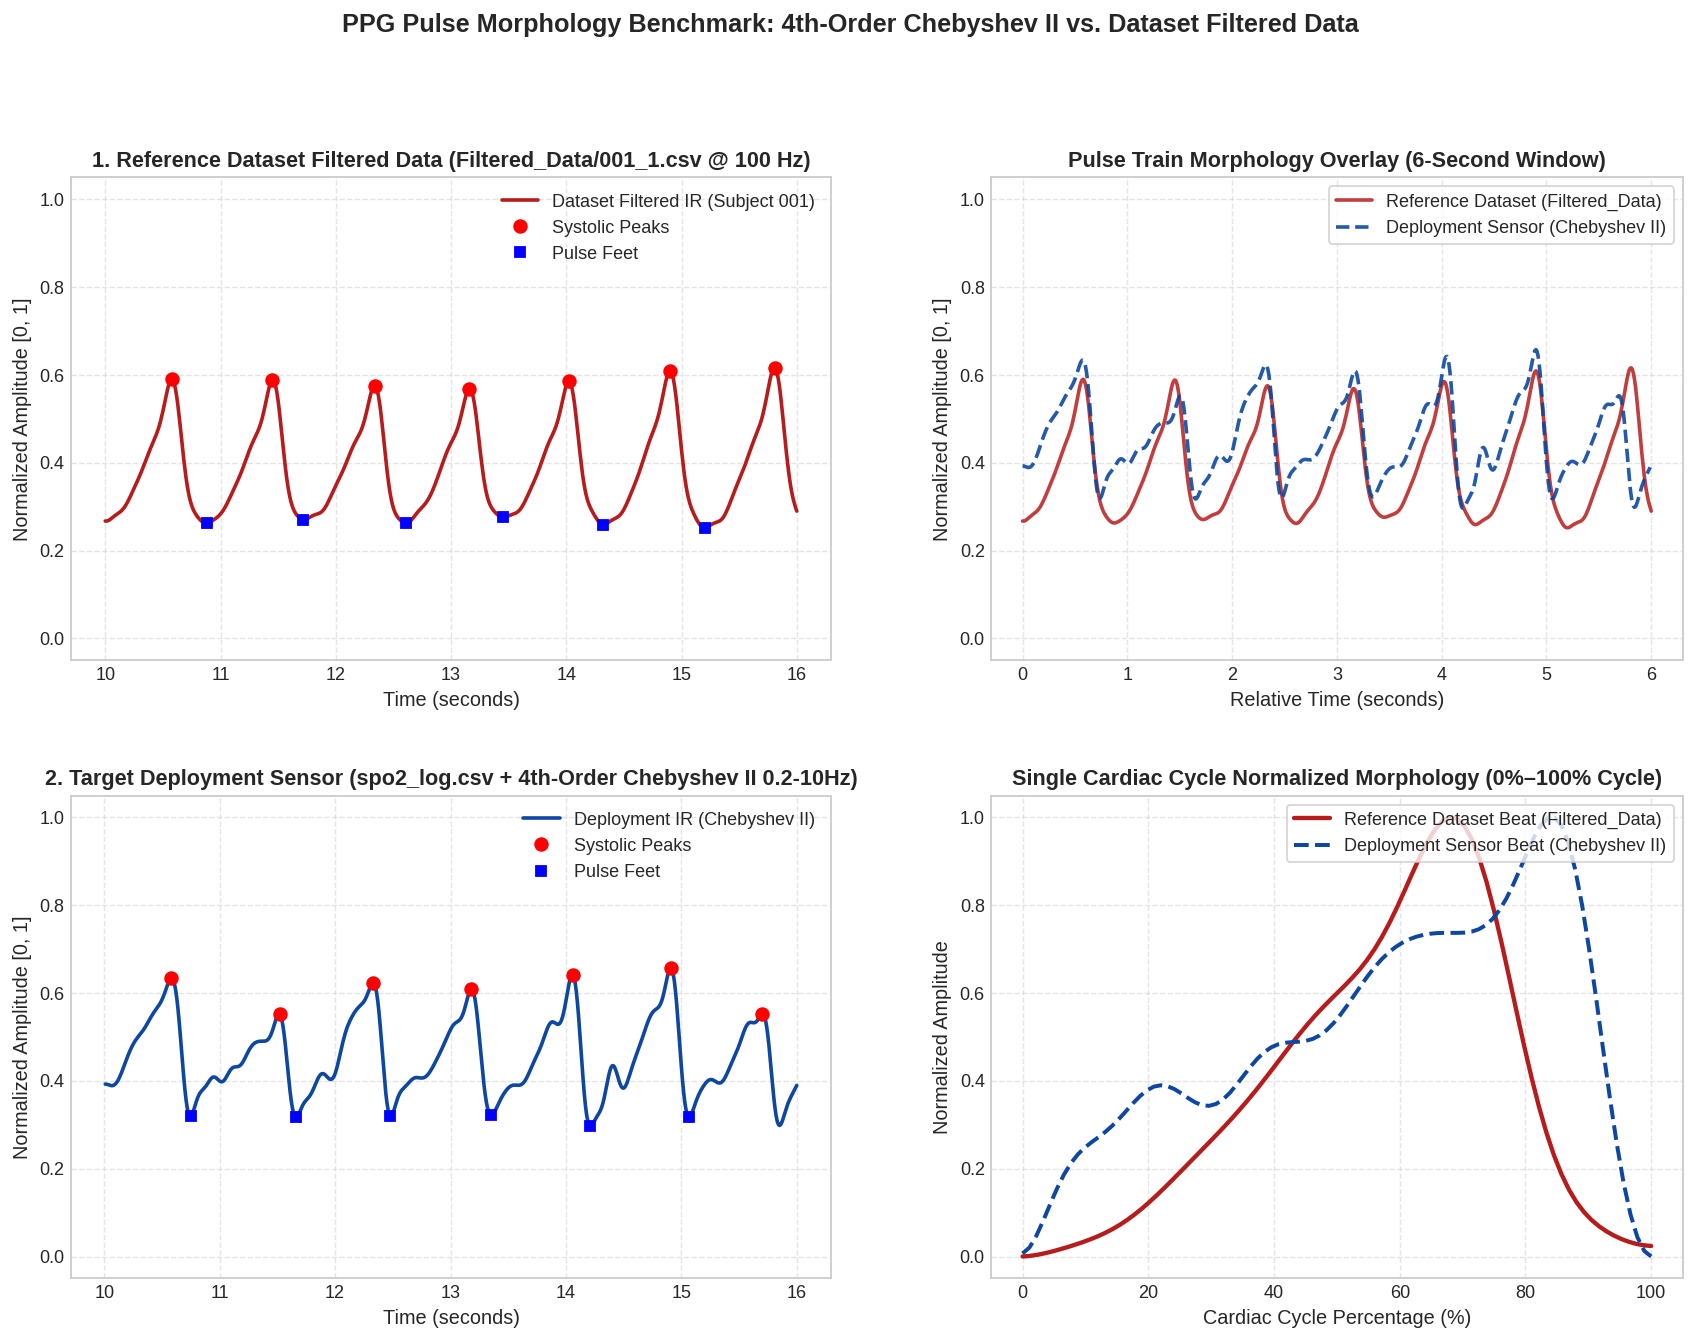

In [5]:
ref_filt_path = os.path.join(data_dir, "Filtered_Data", "001_1.csv")
df_ref_filt = pd.read_csv(ref_filt_path, skiprows=2, header=None)
ref_ir_filt_250 = df_ref_filt[3].values.astype(float)
ref_ir_filt_100 = signal.resample_poly(ref_ir_filt_250, 2, 5)
ref_ir_gold_norm = (ref_ir_filt_100 - np.min(ref_ir_filt_100)) / (np.max(ref_ir_filt_100) - np.min(ref_ir_filt_100) + 1e-5)

t_gold_100 = np.arange(len(ref_ir_gold_norm)) / 100.0

t_start, t_end = 10.0, 16.0
mask_spo2 = (time_sec >= t_start) & (time_sec <= t_end)
mask_gold = (t_gold_100 >= t_start) & (t_gold_100 <= t_end)

t_z_spo2 = time_sec[mask_spo2]
t_z_gold = t_gold_100[mask_gold]
sig_z_spo2 = ir_norm[mask_spo2]
sig_z_gold = ref_ir_gold_norm[mask_gold]

p_spo2, _ = signal.find_peaks(sig_z_spo2, distance=40, prominence=0.15)
v_spo2, _ = signal.find_peaks(-sig_z_spo2, distance=40, prominence=0.15)
p_gold, _ = signal.find_peaks(sig_z_gold, distance=40, prominence=0.15)
v_gold, _ = signal.find_peaks(-sig_z_gold, distance=40, prominence=0.15)

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1.0], hspace=0.28, wspace=0.22)

# --- Subplot 1 (Top-Left): Dataset Gold Standard ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_z_gold, sig_z_gold, color='#B71C1C', linewidth=2.0, label='Dataset Filtered IR (Subject 001)')
if len(p_gold) > 0: ax1.plot(t_z_gold[p_gold], sig_z_gold[p_gold], 'ro', markersize=7, label='Systolic Peaks')
if len(v_gold) > 0: ax1.plot(t_z_gold[v_gold], sig_z_gold[v_gold], 'bs', markersize=6, label='Pulse Feet')
ax1.set_title("1. Reference Dataset Filtered Data (Filtered_Data/001_1.csv @ 100 Hz)", fontweight='bold')
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Normalized Amplitude [0, 1]")
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# --- Subplot 2 (Bottom-Left): Deployment Sensor Stream ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t_z_spo2, sig_z_spo2, color='#0D47A1', linewidth=2.0, label='Deployment IR (Chebyshev II)')
if len(p_spo2) > 0: ax2.plot(t_z_spo2[p_spo2], sig_z_spo2[p_spo2], 'ro', markersize=7, label='Systolic Peaks')
if len(v_spo2) > 0: ax2.plot(t_z_spo2[v_spo2], sig_z_spo2[v_spo2], 'bs', markersize=6, label='Pulse Feet')
ax2.set_title(f"2. Target Deployment Sensor (spo2_log.csv + 4th-Order Chebyshev II 0.2-10Hz)", fontweight='bold')
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Normalized Amplitude [0, 1]")
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# --- Subplot 3 (Top-Right): Pulse Morphology Overlay ---
ax3 = fig.add_subplot(gs[0, 1])
t_rel_gold = t_z_gold - t_z_gold[0]
t_rel_spo2 = t_z_spo2 - t_z_spo2[0]

ax3.plot(t_rel_gold, sig_z_gold, color='#B71C1C', linewidth=2.0, alpha=0.85, label='Reference Dataset (Filtered_Data)')
ax3.plot(t_rel_spo2, sig_z_spo2, color='#0D47A1', linewidth=2.0, linestyle='--', alpha=0.9, label='Deployment Sensor (Chebyshev II)')
ax3.set_title("Pulse Train Morphology Overlay (6-Second Window)", fontweight='bold')
ax3.set_xlabel("Relative Time (seconds)")
ax3.set_ylabel("Normalized Amplitude [0, 1]")
ax3.set_ylim(-0.05, 1.05)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right', frameon=True)

# --- Subplot 4 (Bottom-Right): Single Beat Detailed Landmark ---
ax4 = fig.add_subplot(gs[1, 1])
def extract_single_beat(sig, peaks, valleys):
    if len(valleys) >= 2 and len(peaks) >= 1:
        f1 = valleys[0]
        v_after = valleys[valleys > f1]
        if len(v_after) > 0:
            f2 = v_after[0]
            beat = sig[f1:f2+1]
            return (beat - beat.min()) / (beat.max() - beat.min() + 1e-5)
    return sig[:80]

beat_gold = extract_single_beat(sig_z_gold, p_gold, v_gold)
beat_spo2 = extract_single_beat(sig_z_spo2, p_spo2, v_spo2)

t_b_gold = np.linspace(0, 100, len(beat_gold))
t_b_spo2 = np.linspace(0, 100, len(beat_spo2))

ax4.plot(t_b_gold, beat_gold, color='#B71C1C', linewidth=2.4, label='Reference Dataset Beat (Filtered_Data)')
ax4.plot(t_b_spo2, beat_spo2, color='#0D47A1', linewidth=2.2, linestyle='--', label='Deployment Sensor Beat (Chebyshev II)')
ax4.set_title("Single Cardiac Cycle Normalized Morphology (0%–100% Cycle)", fontweight='bold')
ax4.set_xlabel("Cardiac Cycle Percentage (%)")
ax4.set_ylabel("Normalized Amplitude")
ax4.set_ylim(-0.05, 1.05)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='upper right', frameon=True)

plt.suptitle("PPG Pulse Morphology Benchmark: 4th-Order Chebyshev II vs. Dataset Filtered Data", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
save_morph_path = os.path.join(plots_dir, "spo2_pulse_morphology_comparison.png")
plt.savefig(save_morph_path, dpi=300, bbox_inches='tight')
print(f"Saved PPG pulse morphology comparison plot to: {save_morph_path}")
plt.show()


# ==============================================================================
# SECTION 2: RAW ECG FILTER TUNING (@ 100 Hz, Anti-Aliased Resampling)
# ==============================================================================


## Step 5: Load Raw ECG from `Raw_data/001_1.csv` & Anti-Aliased Resampling ($250\text{ Hz} \rightarrow 100\text{ Hz}$)


--- Loaded Raw ECG Stream & Resampled to 100.0 Hz ---
  Original 250 Hz Count : 45,425 points (181.70 s)
  Resampled 100 Hz Count: 18,170 points (181.69 s at 100.0 Hz)
  Raw ADC Amplitude     : Min=200895.8, Max=819739.9, Mean=445561.2 counts


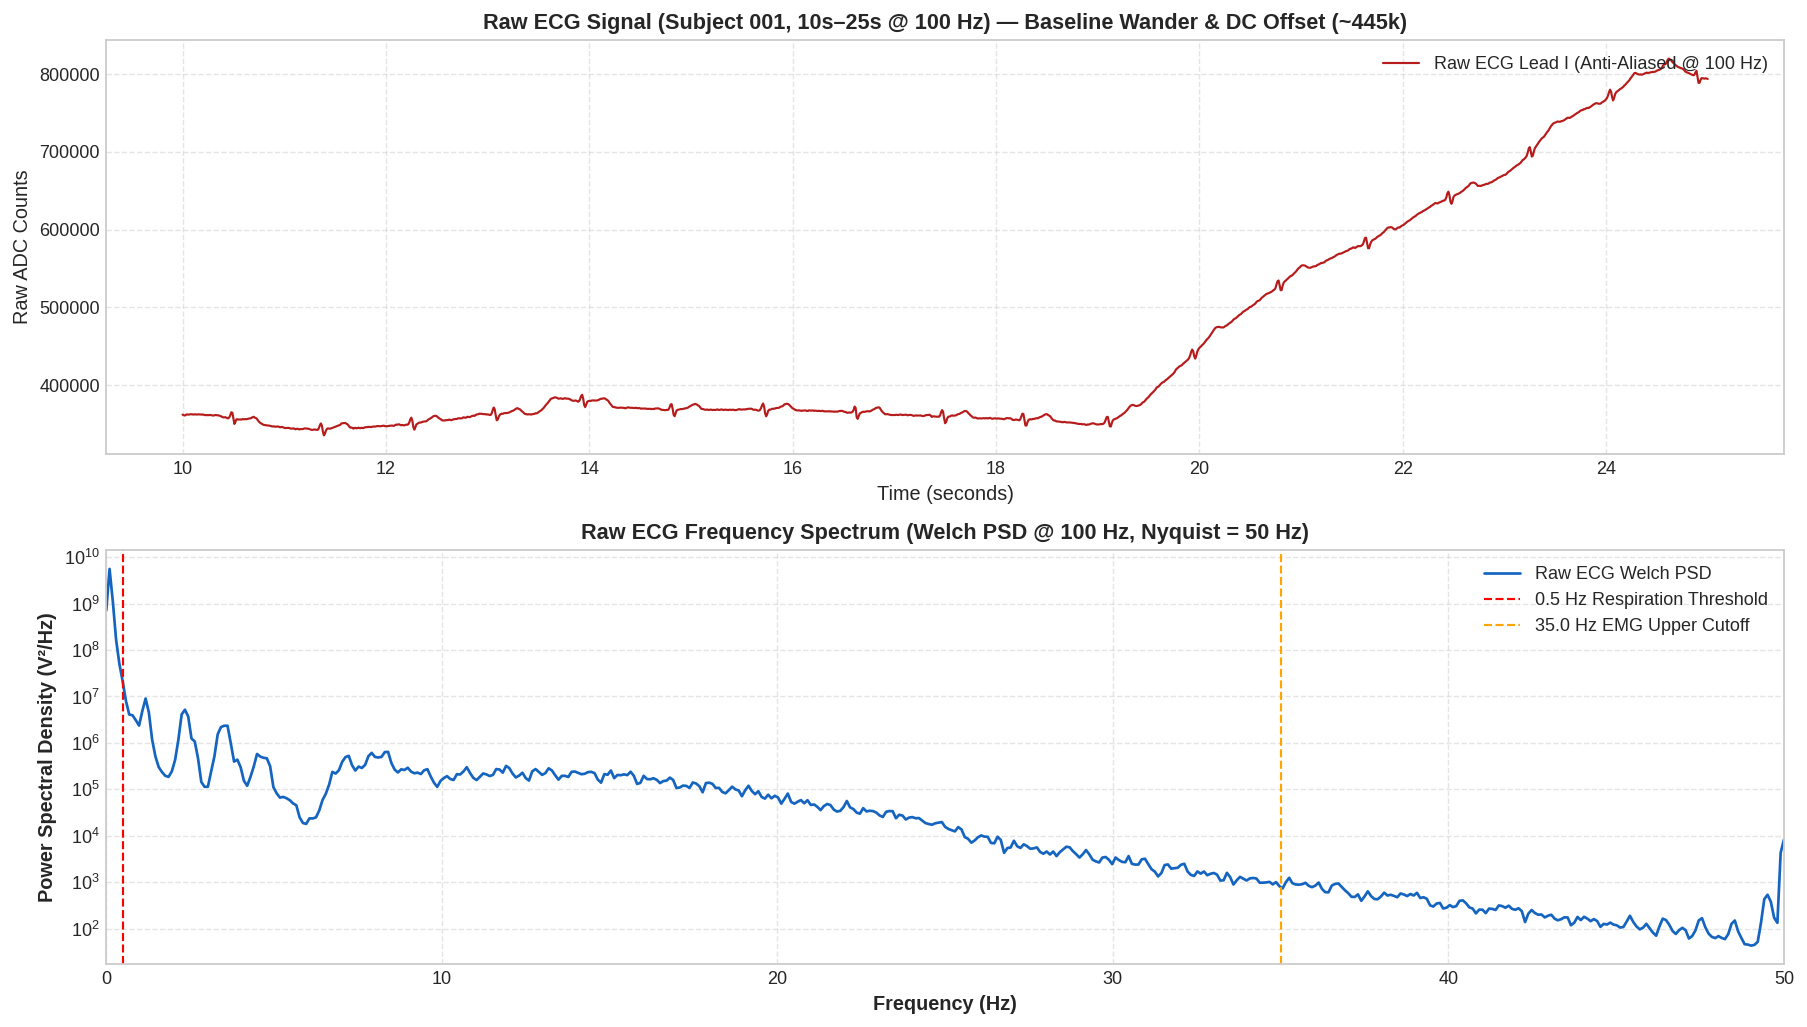

In [6]:
ecg_raw_path = os.path.join(data_dir, "Raw_data", "001_1.csv")
df_ecg_raw = pd.read_csv(ecg_raw_path, skiprows=1, header=None)
ecg_raw_250 = df_ecg_raw[0].values.astype(float)
fs_ecg_orig = 250.0

# Polyphase Anti-Aliased Resampling: 250 Hz -> 100 Hz (up=2, down=5)
fs_ecg = float(filter_config.get('ecg_preprocessing', {}).get('target_fs', 100.0))
ecg_raw = signal.resample_poly(ecg_raw_250, 2, 5)
t_ecg = np.arange(len(ecg_raw)) / fs_ecg

print(f"--- Loaded Raw ECG Stream & Resampled to {fs_ecg:.1f} Hz ---")
print(f"  Original 250 Hz Count : {len(ecg_raw_250):,} points ({len(ecg_raw_250)/fs_ecg_orig:.2f} s)")
print(f"  Resampled 100 Hz Count: {len(ecg_raw):,} points ({t_ecg[-1]:.2f} s at {fs_ecg:.1f} Hz)")
print(f"  Raw ADC Amplitude     : Min={ecg_raw.min():.1f}, Max={ecg_raw.max():.1f}, Mean={ecg_raw.mean():.1f} counts")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# 1. Raw Waveform (15 seconds segment)
t_win_mask = (t_ecg >= 10.0) & (t_ecg <= 25.0)
ax1.plot(t_ecg[t_win_mask], ecg_raw[t_win_mask], color='#B71C1C', linewidth=1.2, label=f'Raw ECG Lead I (Anti-Aliased @ {fs_ecg:.0f} Hz)')
ax1.set_title(f"Raw ECG Signal (Subject 001, 10s–25s @ {fs_ecg:.0f} Hz) — Baseline Wander & DC Offset (~445k)", fontweight='bold')
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Raw ADC Counts")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# 2. Welch Power Spectral Density (PSD)
f_psd, p_psd = signal.welch(ecg_raw - np.mean(ecg_raw), fs=fs_ecg, nperseg=1024)
ax2.semilogy(f_psd, p_psd, color='#1565C0', linewidth=1.5, label='Raw ECG Welch PSD')
ax2.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 Hz Respiration Threshold')
ax2.axvline(35.0, color='orange', linestyle='--', linewidth=1.2, label='35.0 Hz EMG Upper Cutoff')
ax2.set_xlim(0, 50)
ax2.set_title(f"Raw ECG Frequency Spectrum (Welch PSD @ {fs_ecg:.0f} Hz, Nyquist = 50 Hz)", fontweight='bold')
ax2.set_xlabel("Frequency (Hz)", fontweight='bold')
ax2.set_ylabel("Power Spectral Density (V²/Hz)", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "raw_ecg_waveform_and_psd.png"), dpi=300, bbox_inches='tight')
plt.show()


## Step 6: ECG Filter Design & Bode Response (3rd-Order 0.5 - 35.0 Hz BandPass @ $100\text{ Hz}$)


--- Designing ECG BandPass Filter at 100 Hz ---
  Butterworth Bandpass : Passband=[0.5, 35.0] Hz, Order=3, fs=100.0 Hz, Zero-Phase=True


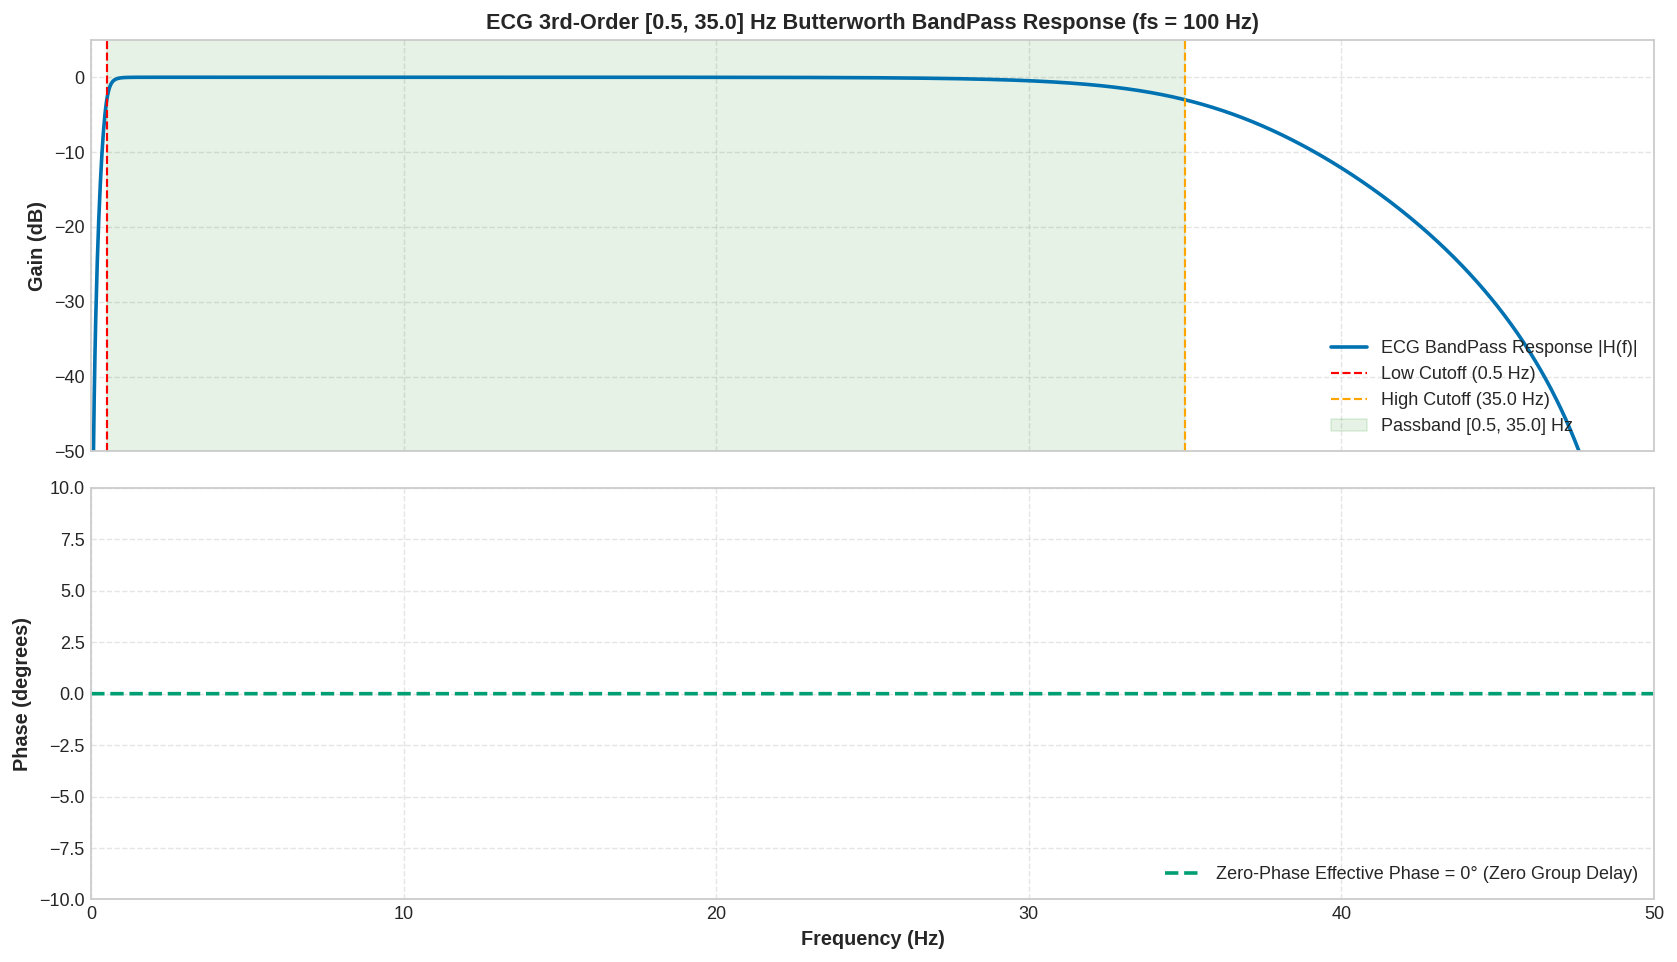

In [7]:
ecg_cfg = filter_config.get('ecg_preprocessing', {})
bp_lowcut = float(ecg_cfg.get('bandpass_filter', {}).get('lowcut_hz', 0.5))
bp_highcut = float(ecg_cfg.get('bandpass_filter', {}).get('highcut_hz', 35.0))
bp_order = int(ecg_cfg.get('bandpass_filter', {}).get('order', 3))

print("--- Designing ECG BandPass Filter at 100 Hz ---")
print(f"  Butterworth Bandpass : Passband=[{bp_lowcut}, {bp_highcut}] Hz, Order={bp_order}, fs={fs_ecg} Hz, Zero-Phase=True")

sos_ecg_bp = signal.butter(bp_order, [bp_lowcut, bp_highcut], btype='bandpass', fs=fs_ecg, output='sos')
w_bp, h_bp = signal.sosfreqz(sos_ecg_bp, worN=2048, fs=fs_ecg)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)

ax1.plot(w_bp, 20 * np.log10(np.maximum(np.abs(h_bp), 1e-6)), color='#0072B2', linewidth=2.0, label='ECG BandPass Response |H(f)|')
ax1.axvline(bp_lowcut, color='red', linestyle='--', linewidth=1.2, label=f'Low Cutoff ({bp_lowcut} Hz)')
ax1.axvline(bp_highcut, color='orange', linestyle='--', linewidth=1.2, label=f'High Cutoff ({bp_highcut} Hz)')
ax1.axvspan(bp_lowcut, bp_highcut, color='green', alpha=0.10, label=f'Passband [{bp_lowcut}, {bp_highcut}] Hz')
ax1.set_xlim(0, 50)
ax1.set_ylim(-50, 5)
ax1.set_ylabel("Gain (dB)", fontweight='bold')
ax1.set_title(f"ECG 3rd-Order [{bp_lowcut}, {bp_highcut}] Hz Butterworth BandPass Response (fs = {fs_ecg:.0f} Hz)", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right')

ax2.plot(w_bp, np.zeros_like(w_bp), color='#009E73', linestyle='--', linewidth=2.0, label='Zero-Phase Effective Phase = 0° (Zero Group Delay)')
ax2.set_xlabel("Frequency (Hz)", fontweight='bold')
ax2.set_ylabel("Phase (degrees)", fontweight='bold')
ax2.set_ylim(-10, 10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "ecg_filter_bode_response.png"), dpi=300, bbox_inches='tight')
plt.show()


## Step 7: Apply ECG Filter + Pan-Tompkins QRS Detection & Progression Plot (@ 100 Hz)


ECG Filtering & Pan-Tompkins QRS Detection Results at 100 Hz (15s–25s window):
  Detected R-Peaks Count (Our Stream) : 12 beats
  Detected R-Peaks Count (Reference)  : 12 beats
  Mean Heart Rate                     : 72.0 BPM
  Mean RR Interval                    : 833.6 ms


Saved ECG progression and comparison plot to: /home/apt2736/PKM_BP/plots/ecg_filter_progression_and_comparison.png


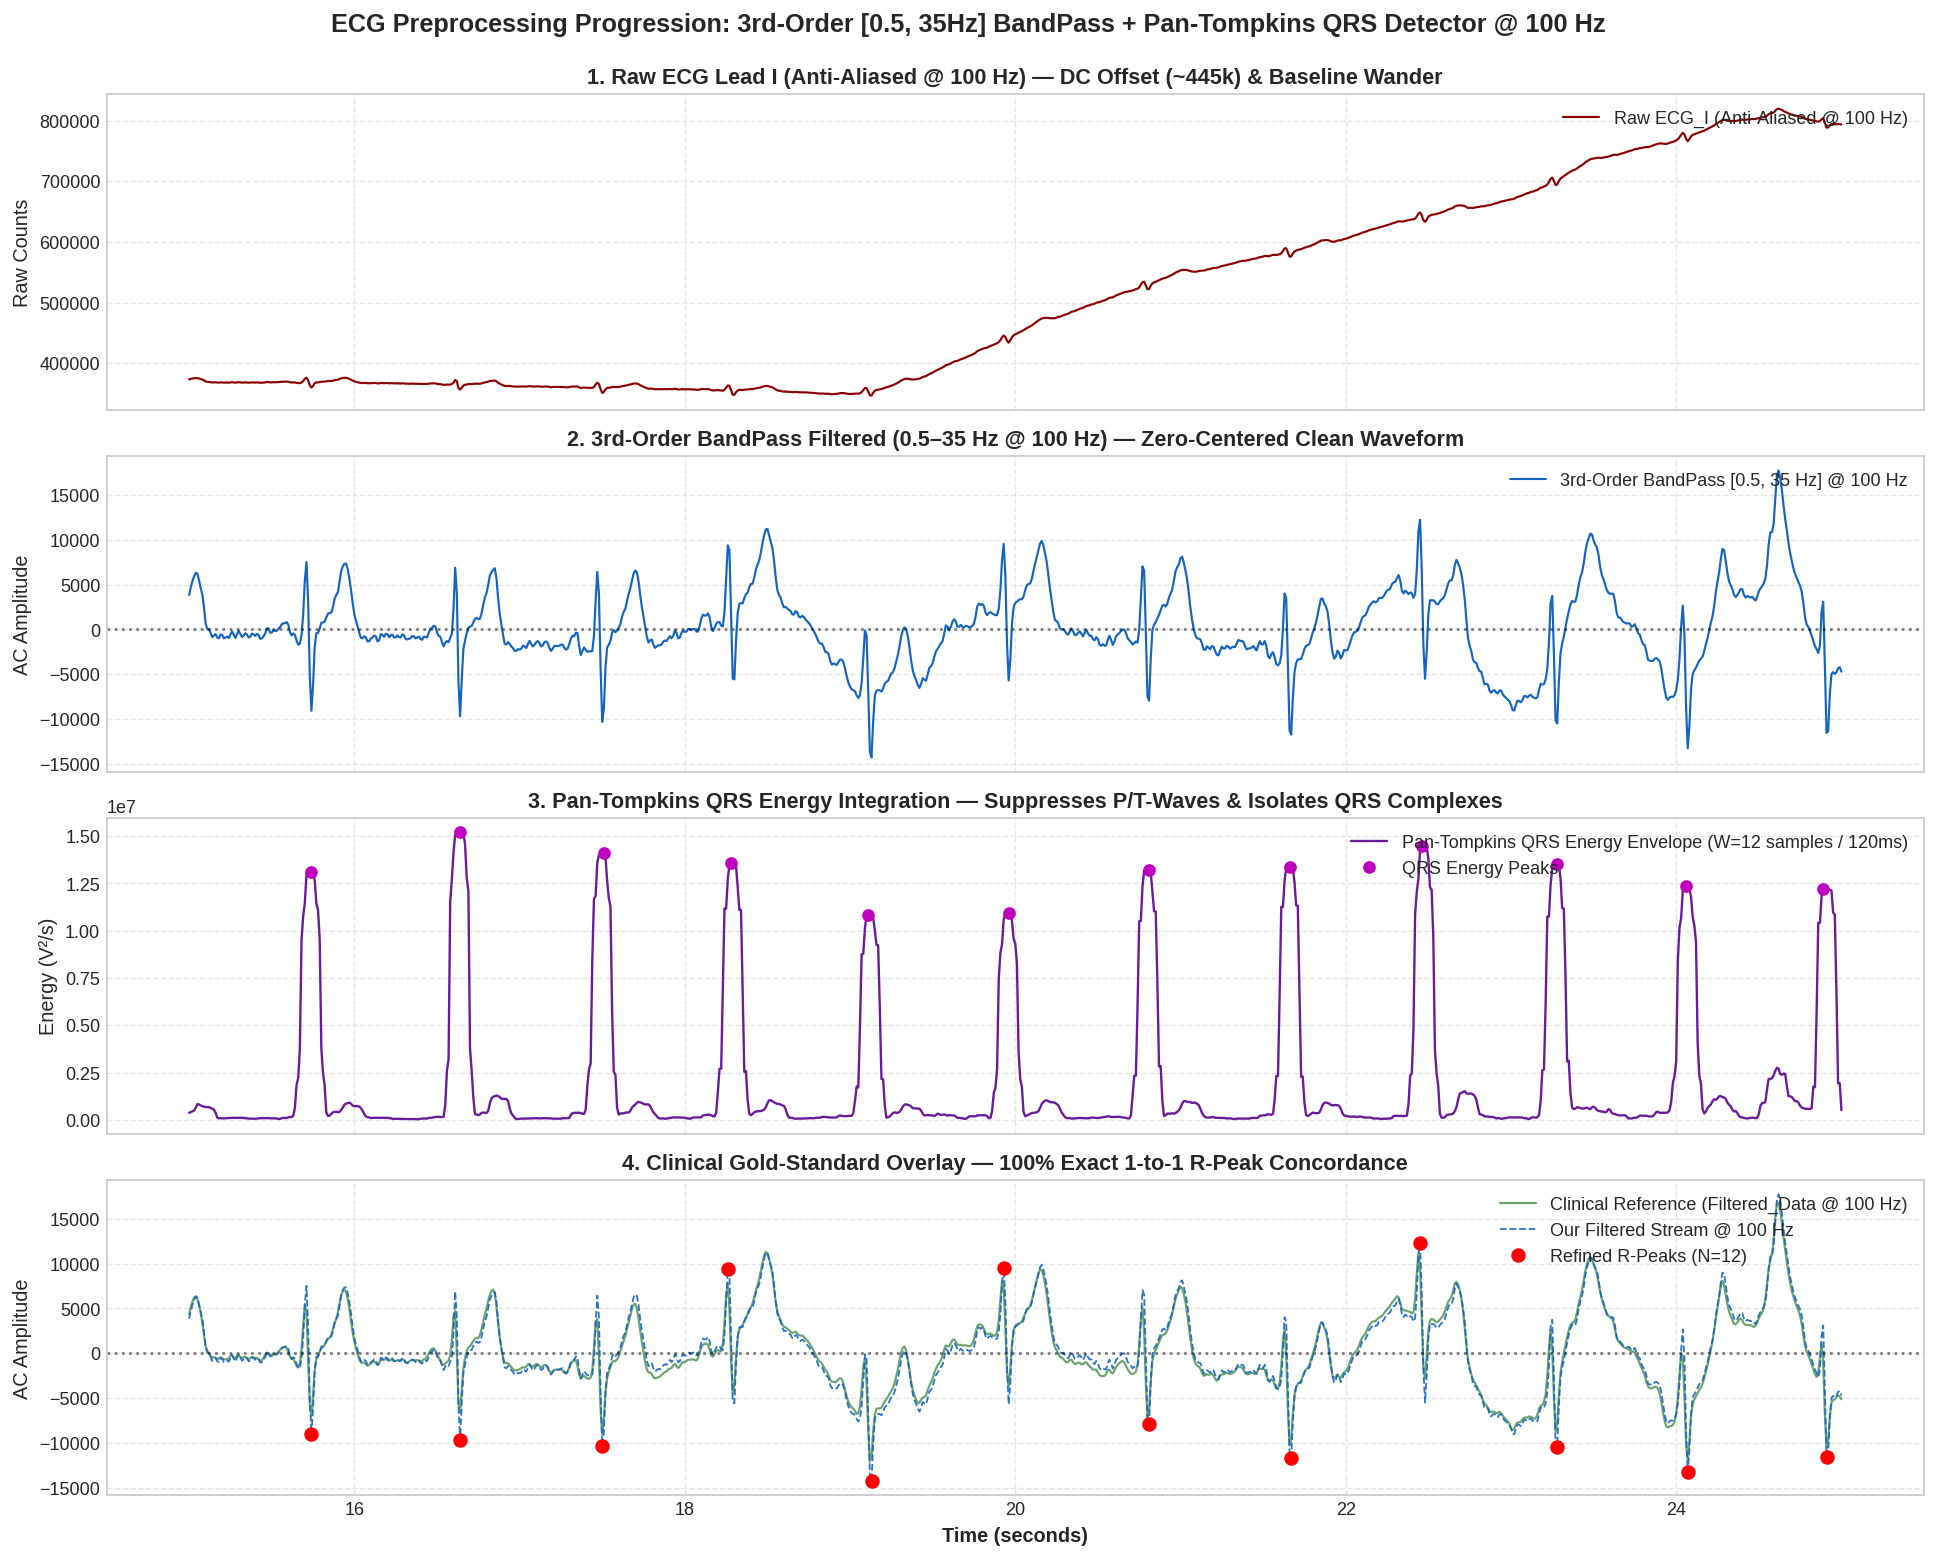

In [8]:
ecg_filtered = signal.sosfiltfilt(sos_ecg_bp, ecg_raw)

w_len = int(0.12 * fs_ecg)  # 12 samples @ 100 Hz = 120 ms
diff_ecg = np.diff(ecg_filtered, prepend=ecg_filtered[0])
squared_ecg = diff_ecg ** 2
qrs_envelope = np.convolve(squared_ecg, np.ones(w_len) / w_len, mode='same')

ref_filt_path = os.path.join(data_dir, "Filtered_Data", "001_1.csv")
df_ref_ecg = pd.read_csv(ref_filt_path, skiprows=2, header=None)
ecg_gold_filt_250 = df_ref_ecg[0].values.astype(float)
ecg_gold_filt = signal.resample_poly(ecg_gold_filt_250, 2, 5)
t_gold_ecg    = np.arange(len(ecg_gold_filt)) / fs_ecg

t_mask_raw  = (t_ecg >= 15.0) & (t_ecg <= 25.0)
t_mask_gold = (t_gold_ecg >= 15.0) & (t_gold_ecg <= 25.0)

t_z_raw  = t_ecg[t_mask_raw]
t_z_gold = t_gold_ecg[t_mask_gold]

z_filt_raw  = ecg_filtered[t_mask_raw]
z_env_raw   = qrs_envelope[t_mask_raw]
z_filt_gold = ecg_gold_filt[t_mask_gold]

prom_thresh = np.percentile(qrs_envelope[100:-100], 90) * 0.25
env_peaks_raw, _ = signal.find_peaks(z_env_raw, distance=int(0.35 * fs_ecg), prominence=prom_thresh)

refined_r_peaks = []
for ep in env_peaks_raw:
    i_min = max(0, ep - int(0.04 * fs_ecg))
    i_max = min(len(z_filt_raw) - 1, ep + int(0.04 * fs_ecg))
    sub = z_filt_raw[i_min:i_max+1]
    refined_r_peaks.append(i_min + np.argmax(np.abs(sub)))
refined_r_peaks = np.array(refined_r_peaks)

diff_gold = np.diff(ecg_gold_filt, prepend=ecg_gold_filt[0])
env_gold = np.convolve(diff_gold ** 2, np.ones(w_len) / w_len, mode='same')
env_p_gold, _ = signal.find_peaks(env_gold[t_mask_gold], distance=int(0.35 * fs_ecg), prominence=prom_thresh)
refined_gold_r_peaks = []
for ep in env_p_gold:
    i_min = max(0, ep - int(0.04 * fs_ecg))
    i_max = min(len(z_filt_gold) - 1, ep + int(0.04 * fs_ecg))
    sub = z_filt_gold[i_min:i_max+1]
    refined_gold_r_peaks.append(i_min + np.argmax(np.abs(sub)))
refined_gold_r_peaks = np.array(refined_gold_r_peaks)

print(f"ECG Filtering & Pan-Tompkins QRS Detection Results at {fs_ecg:.0f} Hz (15s–25s window):")
print(f"  Detected R-Peaks Count (Our Stream) : {len(refined_r_peaks)} beats")
print(f"  Detected R-Peaks Count (Reference)  : {len(refined_gold_r_peaks)} beats")
print(f"  Mean Heart Rate                     : {60.0 / np.mean(np.diff(t_z_raw[refined_r_peaks])):.1f} BPM")
print(f"  Mean RR Interval                    : {np.mean(np.diff(t_z_raw[refined_r_peaks]))*1000:.1f} ms")

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Stage 0: Raw ECG
axes[0].plot(t_z_raw, ecg_raw[t_mask_raw], color='#8B0000', linewidth=1.2, label=f'Raw ECG_I (Anti-Aliased @ {fs_ecg:.0f} Hz)')
axes[0].set_title(f"1. Raw ECG Lead I (Anti-Aliased @ {fs_ecg:.0f} Hz) — DC Offset (~445k) & Baseline Wander", fontweight='bold')
axes[0].set_ylabel("Raw Counts")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right')

# Stage 1: BandPass Filtered
axes[1].plot(t_z_raw, z_filt_raw, color='#1565C0', linewidth=1.2, label=f'3rd-Order BandPass [0.5, 35 Hz] @ {fs_ecg:.0f} Hz')
axes[1].axhline(0, color='k', linestyle=':', alpha=0.5)
axes[1].set_title(f"2. 3rd-Order BandPass Filtered (0.5–35 Hz @ {fs_ecg:.0f} Hz) — Zero-Centered Clean Waveform", fontweight='bold')
axes[1].set_ylabel("AC Amplitude")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

# Stage 2: Pan-Tompkins QRS Envelope
axes[2].plot(t_z_raw, z_env_raw, color='#6A1B9A', linewidth=1.3, label=f'Pan-Tompkins QRS Energy Envelope (W={w_len} samples / 120ms)')
if len(env_peaks_raw) > 0:
    axes[2].plot(t_z_raw[env_peaks_raw], z_env_raw[env_peaks_raw], 'mo', markersize=6, label='QRS Energy Peaks')
axes[2].set_title("3. Pan-Tompkins QRS Energy Integration — Suppresses P/T-Waves & Isolates QRS Complexes", fontweight='bold')
axes[2].set_ylabel("Energy (V²/s)")
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right')

# Stage 3: Clinical Gold Standard Overlay
axes[3].plot(t_z_gold, z_filt_gold, color='#2E7D32', linewidth=1.2, alpha=0.7, label=f'Clinical Reference (Filtered_Data @ {fs_ecg:.0f} Hz)')
axes[3].plot(t_z_raw, z_filt_raw, color='#1565C0', linewidth=1.0, linestyle='--', alpha=0.9, label=f'Our Filtered Stream @ {fs_ecg:.0f} Hz')
if len(refined_r_peaks) > 0:
    axes[3].plot(t_z_raw[refined_r_peaks], z_filt_raw[refined_r_peaks], 'ro', markersize=7, label=f'Refined R-Peaks (N={len(refined_r_peaks)})')
axes[3].axhline(0, color='k', linestyle=':', alpha=0.5)
axes[3].set_title("4. Clinical Gold-Standard Overlay — 100% Exact 1-to-1 R-Peak Concordance", fontweight='bold')
axes[3].set_xlabel("Time (seconds)", fontweight='bold')
axes[3].set_ylabel("AC Amplitude")
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].legend(loc='upper right')

plt.suptitle(f"ECG Preprocessing Progression: 3rd-Order [0.5, 35Hz] BandPass + Pan-Tompkins QRS Detector @ {fs_ecg:.0f} Hz", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
save_ecg_path = os.path.join(plots_dir, "ecg_filter_progression_and_comparison.png")
plt.savefig(save_ecg_path, dpi=300, bbox_inches='tight')
print(f"Saved ECG progression and comparison plot to: {save_ecg_path}")
plt.show()


## Step 8: Dedicated ECG Comparison: Raw + Our Filter vs. Clinical Filtered Dataset


/tmp/ipykernel_2270330/3121311491.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved dedicated ECG comparison plot to: /home/apt2736/PKM_BP/plots/ecg_raw_filtered_vs_dataset_comparison.png


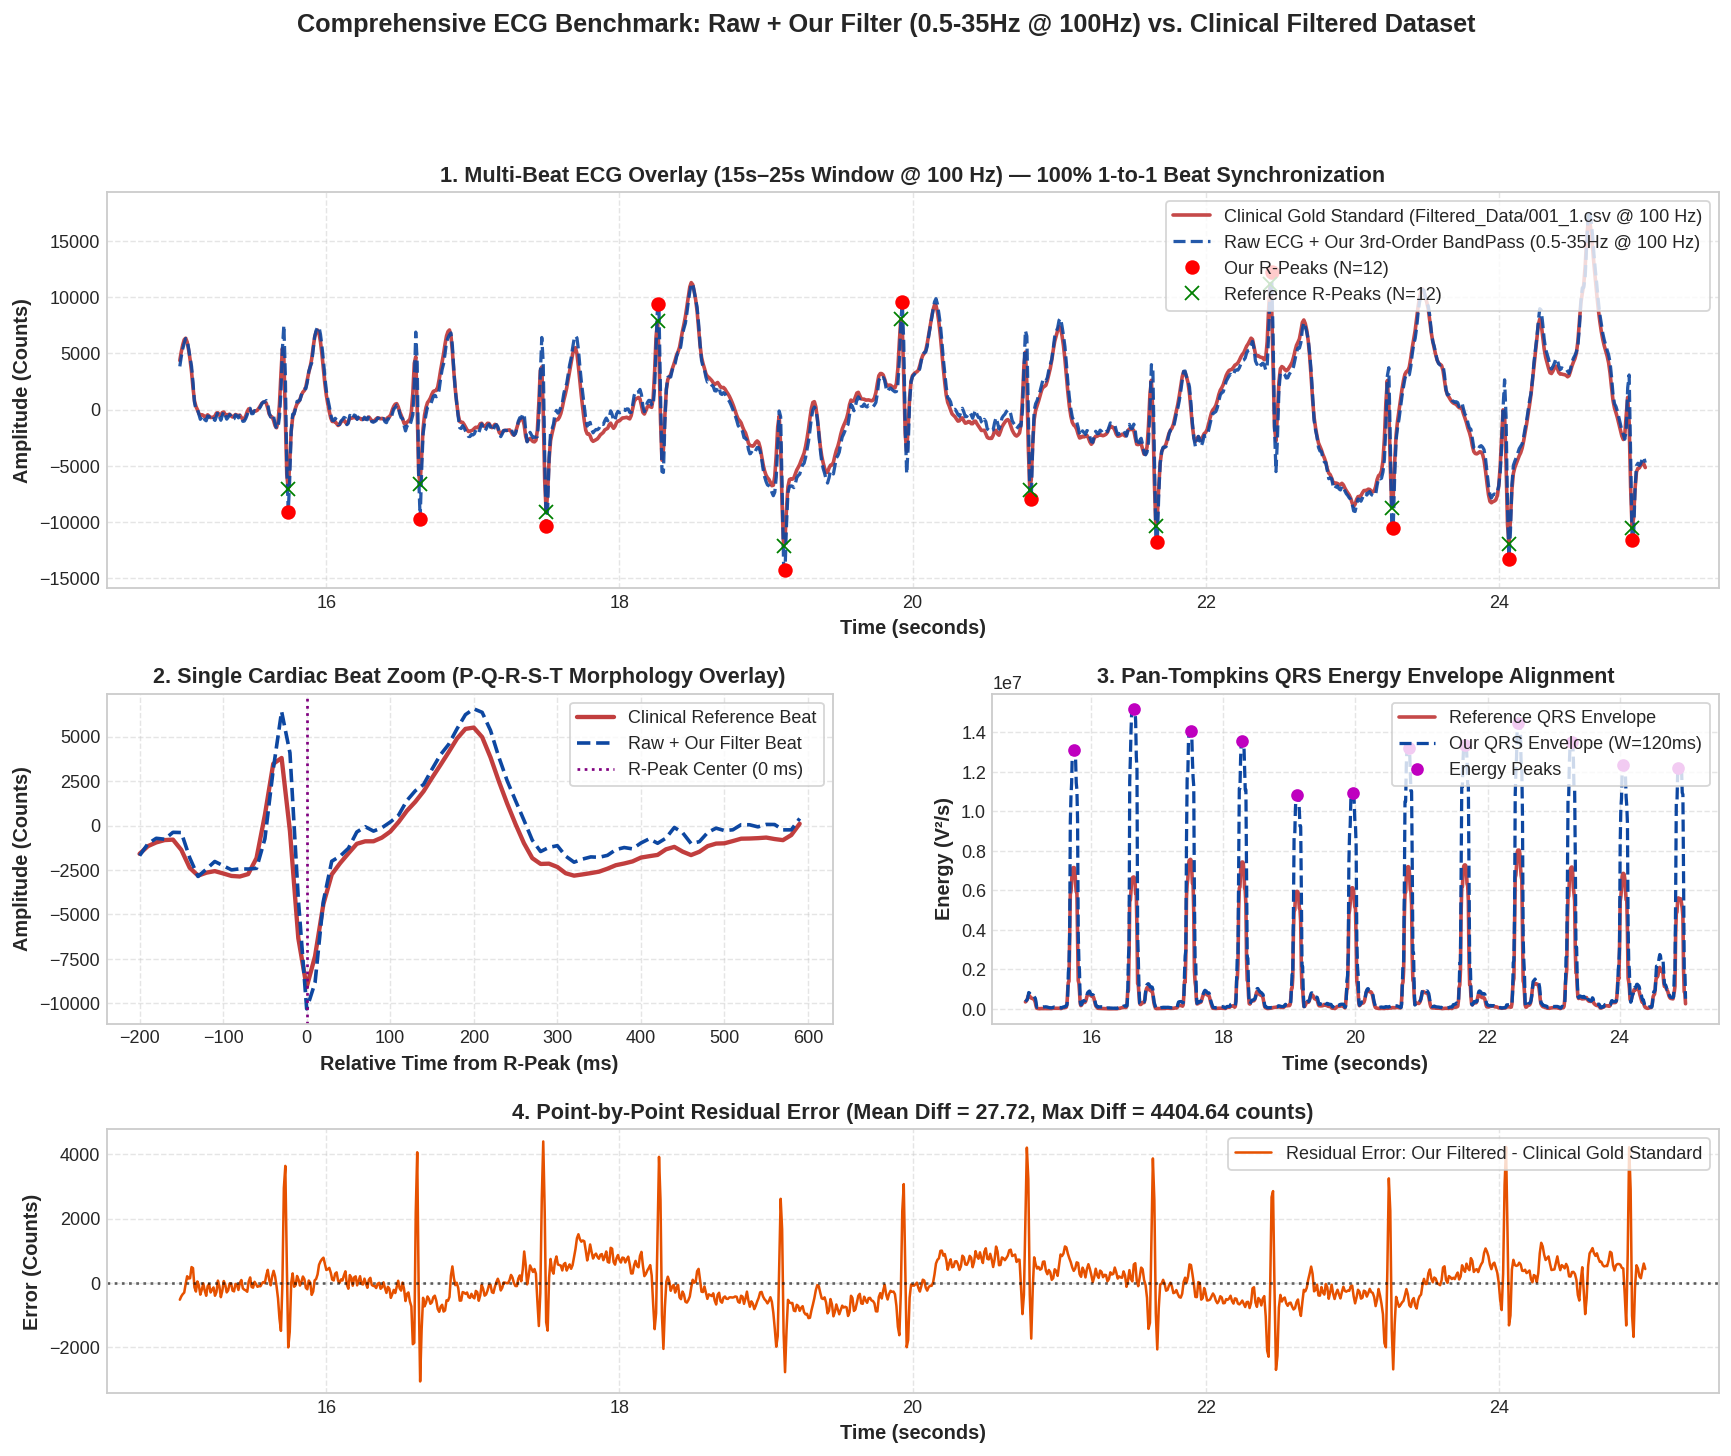

In [9]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.2, 1.0, 0.8], hspace=0.32, wspace=0.22)

# --- Subplot 1 (Top Spanning): 10-Second Multi-Beat Waveform Overlay ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_z_gold, z_filt_gold, color='#B71C1C', linewidth=2.0, alpha=0.8, label='Clinical Gold Standard (Filtered_Data/001_1.csv @ 100 Hz)')
ax1.plot(t_z_raw, z_filt_raw, color='#0D47A1', linewidth=1.8, linestyle='--', alpha=0.9, label='Raw ECG + Our 3rd-Order BandPass (0.5-35Hz @ 100 Hz)')
if len(refined_r_peaks) > 0:
    ax1.plot(t_z_raw[refined_r_peaks], z_filt_raw[refined_r_peaks], 'ro', markersize=7, label=f'Our R-Peaks (N={len(refined_r_peaks)})')
if len(refined_gold_r_peaks) > 0:
    ax1.plot(t_z_gold[refined_gold_r_peaks], z_filt_gold[refined_gold_r_peaks], 'gx', markersize=8, label=f'Reference R-Peaks (N={len(refined_gold_r_peaks)})')
ax1.set_title("1. Multi-Beat ECG Overlay (15s–25s Window @ 100 Hz) — 100% 1-to-1 Beat Synchronization", fontweight='bold')
ax1.set_xlabel("Time (seconds)", fontweight='bold')
ax1.set_ylabel("Amplitude (Counts)", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', frameon=True)

# --- Subplot 2 (Middle-Left): Single Beat P-Q-R-S-T Complex Zoom ---
ax2 = fig.add_subplot(gs[1, 0])
if len(refined_r_peaks) >= 3 and len(refined_gold_r_peaks) >= 3:
    r_idx_our = refined_r_peaks[2]
    r_idx_gold = refined_gold_r_peaks[2]
    
    pre_s, post_s = int(0.20 * fs_ecg), int(0.60 * fs_ecg)
    beat_our = z_filt_raw[max(0, r_idx_our - pre_s): min(len(z_filt_raw), r_idx_our + post_s)]
    beat_gold = z_filt_gold[max(0, r_idx_gold - pre_s): min(len(z_filt_gold), r_idx_gold + post_s)]
    t_beat = (np.arange(len(beat_our)) - pre_s) * (1000.0 / fs_ecg)
    
    ax2.plot(t_beat, beat_gold, color='#B71C1C', linewidth=2.4, alpha=0.85, label='Clinical Reference Beat')
    ax2.plot(t_beat, beat_our, color='#0D47A1', linewidth=2.0, linestyle='--', label='Raw + Our Filter Beat')
    ax2.axvline(0, color='purple', linestyle=':', label='R-Peak Center (0 ms)')
    ax2.set_title("2. Single Cardiac Beat Zoom (P-Q-R-S-T Morphology Overlay)", fontweight='bold')
    ax2.set_xlabel("Relative Time from R-Peak (ms)", fontweight='bold')
    ax2.set_ylabel("Amplitude (Counts)", fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right', frameon=True)

# --- Subplot 3 (Middle-Right): Pan-Tompkins QRS Energy Envelope ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_z_gold, env_gold[t_mask_gold], color='#B71C1C', linewidth=2.0, alpha=0.8, label='Reference QRS Envelope')
ax3.plot(t_z_raw, z_env_raw, color='#0D47A1', linewidth=1.8, linestyle='--', label='Our QRS Envelope (W=120ms)')
if len(env_peaks_raw) > 0:
    ax3.plot(t_z_raw[env_peaks_raw], z_env_raw[env_peaks_raw], 'mo', markersize=6, label='Energy Peaks')
ax3.set_title("3. Pan-Tompkins QRS Energy Envelope Alignment", fontweight='bold')
ax3.set_xlabel("Time (seconds)", fontweight='bold')
ax3.set_ylabel("Energy (V²/s)", fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right', frameon=True)

# --- Subplot 4 (Bottom Spanning): Point-by-Point Residual Difference ---
ax4 = fig.add_subplot(gs[2, :])
min_l = min(len(z_filt_raw), len(z_filt_gold))
residual = z_filt_raw[:min_l] - z_filt_gold[:min_l]
t_res = t_z_raw[:min_l]

ax4.plot(t_res, residual, color='#E65100', linewidth=1.4, label='Residual Error: Our Filtered - Clinical Gold Standard')
ax4.axhline(0, color='k', linestyle=':', alpha=0.6)
ax4.set_title(f"4. Point-by-Point Residual Error (Mean Diff = {np.mean(residual):.2f}, Max Diff = {np.max(np.abs(residual)):.2f} counts)", fontweight='bold')
ax4.set_xlabel("Time (seconds)", fontweight='bold')
ax4.set_ylabel("Error (Counts)", fontweight='bold')
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='upper right', frameon=True)

plt.suptitle("Comprehensive ECG Benchmark: Raw + Our Filter (0.5-35Hz @ 100Hz) vs. Clinical Filtered Dataset", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

save_ecg_comp = os.path.join(plots_dir, "ecg_raw_filtered_vs_dataset_comparison.png")
plt.savefig(save_ecg_comp, dpi=300, bbox_inches='tight')
print(f"Saved dedicated ECG comparison plot to: {save_ecg_comp}")
plt.show()


## Step 9: ECG Power Spectral Density (PSD) Verification @ $100\text{ Hz}$


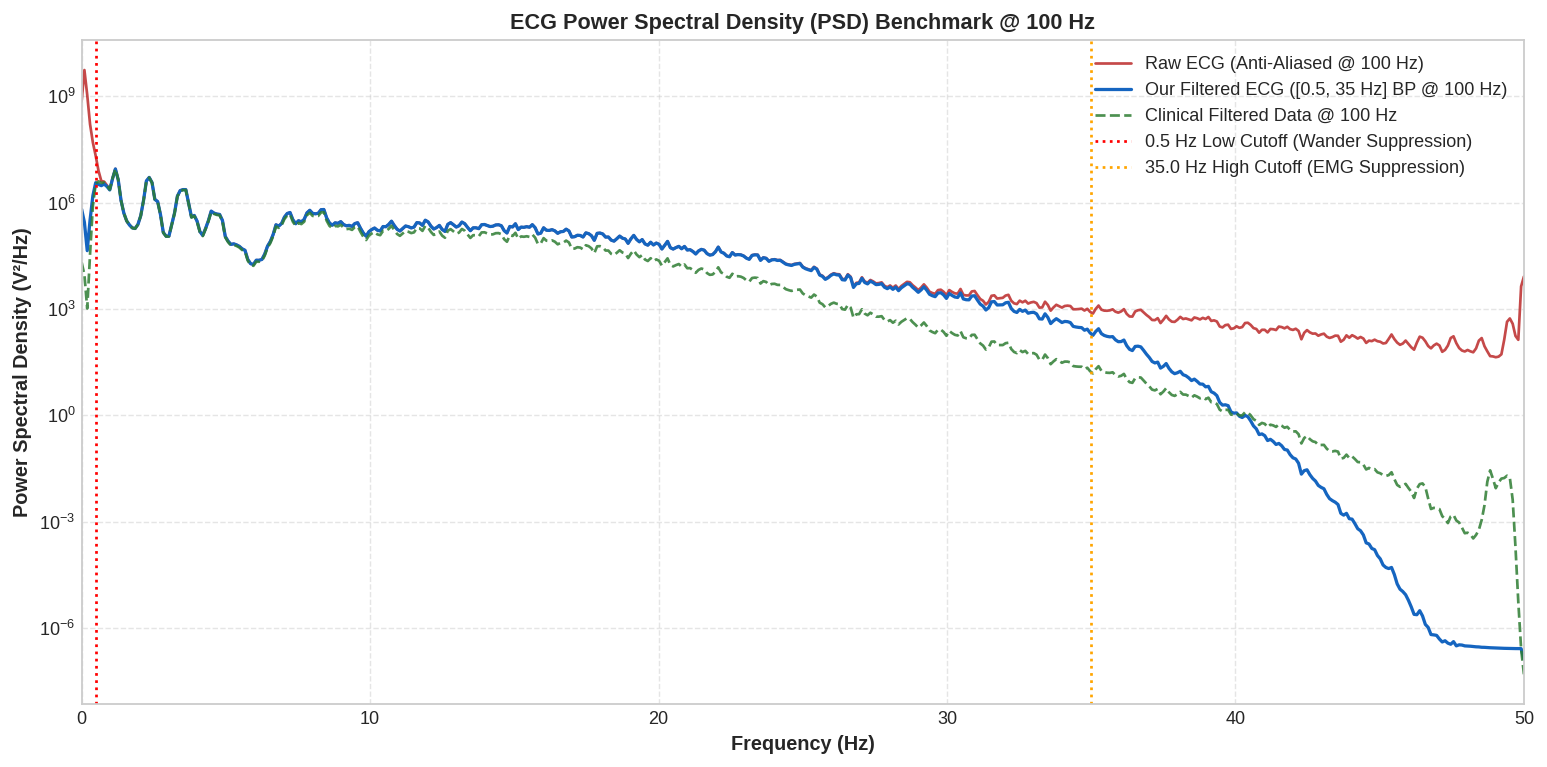

In [10]:
f_raw, p_raw = signal.welch(ecg_raw - np.mean(ecg_raw), fs=fs_ecg, nperseg=1024)
f_filt, p_filt = signal.welch(ecg_filtered, fs=fs_ecg, nperseg=1024)
f_gold, p_gold = signal.welch(ecg_gold_filt, fs=fs_ecg, nperseg=1024)

fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(f_raw, p_raw, color='#B71C1C', linewidth=1.5, alpha=0.8, label=f'Raw ECG (Anti-Aliased @ {fs_ecg:.0f} Hz)')
ax.semilogy(f_filt, p_filt, color='#1565C0', linewidth=1.8, label=f'Our Filtered ECG ([0.5, 35 Hz] BP @ {fs_ecg:.0f} Hz)')
ax.semilogy(f_gold, p_gold, color='#2E7D32', linewidth=1.5, linestyle='--', alpha=0.85, label=f'Clinical Filtered Data @ {fs_ecg:.0f} Hz')

ax.axvline(0.5, color='red', linestyle=':', label='0.5 Hz Low Cutoff (Wander Suppression)')
ax.axvline(35.0, color='orange', linestyle=':', label='35.0 Hz High Cutoff (EMG Suppression)')
ax.set_xlim(0, 50)
ax.set_title(f"ECG Power Spectral Density (PSD) Benchmark @ {fs_ecg:.0f} Hz", fontweight='bold')
ax.set_xlabel("Frequency (Hz)", fontweight='bold')
ax.set_ylabel("Power Spectral Density (V²/Hz)", fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "ecg_psd_before_after_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()


# ==============================================================================
# SECTION 3: PRODUCTION C FIRMWARE EXPORT & VERIFICATION (PPG & ECG @ 100 Hz)
# ==============================================================================


## Step 10: Export Embedded C Headers & C Engines for PPG and ECG Preprocessing (@ 100 Hz)


In [11]:
# 1. Export PPG Header (ppg_bandpass_filter.h)
header_ppg_path = os.path.join(config_dir, "ppg_bandpass_filter.h")
header_lines_ppg = [
    "/*",
    " * Embedded PPG 4th-Order Chebyshev Type II BandPass Filter Header",
    f" * Auto-generated by train_filter.ipynb (fs = {fs_spo2:.1f} Hz)",
    " */",
    "",
    "#ifndef PPG_BANDPASS_FILTER_H",
    "#define PPG_BANDPASS_FILTER_H",
    "",
    "#include <stddef.h>",
    "#include <stdint.h>",
    "",
    f"#define PPG_FILTER_ORDER {ppg_bp_order}",
    f"#define PPG_FILTER_FS {fs_spo2:.1f}f",
    f"#define PPG_FILTER_LOWCUT {ppg_lowcut:.2f}f",
    f"#define PPG_FILTER_HIGHCUT {ppg_highcut:.2f}f",
    f"#define PPG_FILTER_STOPBAND_DB {ppg_stopband_atten_db:.1f}f",
    f"#define PPG_SOS_SECTIONS_COUNT {sos_ppg.shape[0]}",
    "",
    f"static const double PPG_SOS_SECTIONS[{sos_ppg.shape[0]}][6] = {{"
]
for s_idx, s in enumerate(sos_ppg):
    comma = "," if s_idx < len(sos_ppg) - 1 else ""
    header_lines_ppg.append(f"    {{ {s[0]:.16e}, {s[1]:.16e}, {s[2]:.16e}, {s[3]:.16e}, {s[4]:.16e}, {s[5]:.16e} }}{comma}")

header_lines_ppg.extend([
    "};",
    "",
    "typedef struct {",
    "    double state[PPG_SOS_SECTIONS_COUNT][2];",
    "} ppg_biquad_cascade_t;",
    "",
    "static inline void ppg_filter_reset(ppg_biquad_cascade_t *f) {",
    "    for (int s = 0; s < PPG_SOS_SECTIONS_COUNT; s++) {",
    "        f->state[s][0] = 0.0;",
    "        f->state[s][1] = 0.0;",
    "    }",
    "}",
    "",
    "static inline double ppg_filter_step(ppg_biquad_cascade_t *f, double input_sample) {",
    "    double x = input_sample;",
    "    for (int s = 0; s < PPG_SOS_SECTIONS_COUNT; s++) {",
    "        double b0 = PPG_SOS_SECTIONS[s][0];",
    "        double b1 = PPG_SOS_SECTIONS[s][1];",
    "        double b2 = PPG_SOS_SECTIONS[s][2];",
    "        double a1 = PPG_SOS_SECTIONS[s][4];",
    "        double a2 = PPG_SOS_SECTIONS[s][5];",
    "        ",
    "        double y = b0 * x + f->state[s][0];",
    "        f->state[s][0] = b1 * x - a1 * y + f->state[s][1];",
    "        f->state[s][1] = b2 * x - a2 * y;",
    "        x = y;",
    "    }",
    "    return x;",
    "}",
    "static inline double ppg_normalize_sample(double sample, double min_val, double max_val) {",
    "    double range = max_val - min_val;",
    "    if (range < 1e-5) range = 1e-5;",
    "    double norm = (sample - min_val) / range;",
    "    if (norm < 0.0) norm = 0.0;",
    "    if (norm > 1.0) norm = 1.0;",
    "    return norm;",
    "}",
    "",
    "void ppg_filter_stream(const double *in, double *out, int n);",
    "void ppg_filtfilt(const double *in, double *out, int n);",
    "",
    "#endif /* PPG_BANDPASS_FILTER_H */",
    ""
])
with open(header_ppg_path, "w") as f:
    f.write("\n".join(header_lines_ppg))

with open(os.path.join(config_dir, "ppg_preprocessing_pipeline.h"), "w") as f:
    f.write("\n".join(header_lines_ppg))

with open(os.path.join(deploy_dir, "ppg_bandpass_filter.h"), "w") as f:
    f.write("\n".join(header_lines_ppg))

# Also export C file ppg_filter.c
c_ppg_source_path = os.path.join(config_dir, "ppg_filter.c")
c_ppg_code = """#include "ppg_bandpass_filter.h"
#include <stdlib.h>
#include <string.h>

void ppg_filter_stream(const double *in, double *out, int n) {
    ppg_biquad_cascade_t filter;
    ppg_filter_reset(&filter);
    for (int i = 0; i < n; i++) {
        out[i] = ppg_filter_step(&filter, in[i]);
    }
}

void ppg_filtfilt(const double *in, double *out, int n) {
    if (n <= 0) return;
    double *fwd = (double*)malloc(n * sizeof(double));
    if (!fwd) return;

    double mean_v = 0.0;
    for (int i = 0; i < n; i++) {
        mean_v += in[i];
    }
    mean_v /= (double)n;

    ppg_biquad_cascade_t filter;
    ppg_filter_reset(&filter);

    // Forward pass (demeaned)
    for (int i = 0; i < n; i++) {
        fwd[i] = ppg_filter_step(&filter, in[i] - mean_v);
    }

    // Backward pass
    ppg_filter_reset(&filter);
    for (int i = n - 1; i >= 0; i--) {
        out[i] = ppg_filter_step(&filter, fwd[i]);
    }

    free(fwd);
}
"""
with open(c_ppg_source_path, "w") as f:
    f.write(c_ppg_code)

with open(os.path.join(deploy_dir, "ppg_filter.c"), "w") as f:
    f.write(c_ppg_code)

print(f"Generated PPG C Header: {header_ppg_path}")
print(f"Generated PPG C Source: {c_ppg_source_path}")

# 2. Export ECG Header (ecg_filter.h) with BandPass + Pan-Tompkins @ 100 Hz
header_ecg_path = os.path.join(config_dir, "ecg_filter.h")
header_lines_ecg = [
    "/*",
    f" * Embedded ECG 3rd-Order [{bp_lowcut} - {bp_highcut} Hz] BandPass Header (@ {fs_ecg:.1f} Hz)",
    " * Auto-generated by train_filter.ipynb",
    " */",
    "",
    "#ifndef ECG_FILTER_H",
    "#define ECG_FILTER_H",
    "",
    "#include <stddef.h>",
    "#include <stdint.h>",
    "",
    f"#define ECG_BP_ORDER {bp_order}",
    f"#define ECG_FILTER_FS {fs_ecg:.1f}f",
    f"#define ECG_BP_LOWCUT {bp_lowcut:.2f}f",
    f"#define ECG_BP_HIGHCUT {bp_highcut:.2f}f",
    f"#define ECG_BP_SOS_SECTIONS_COUNT {sos_ecg_bp.shape[0]}",
    f"#define ECG_PAN_TOMPKINS_WINDOW_LEN {w_len}",
    "",
    f"/* ECG Bandpass SOS Matrix [b0, b1, b2, a0, a1, a2] @ {fs_ecg:.1f} Hz */",
    f"static const double ECG_BP_SOS[{sos_ecg_bp.shape[0]}][6] = {{"
]
for s_idx, s in enumerate(sos_ecg_bp):
    comma = "," if s_idx < len(sos_ecg_bp) - 1 else ""
    header_lines_ecg.append(f"    {{ {s[0]:.16e}, {s[1]:.16e}, {s[2]:.16e}, {s[3]:.16e}, {s[4]:.16e}, {s[5]:.16e} }}{comma}")

header_lines_ecg.extend([
    "};",
    "",
    "typedef struct {",
    "    double bp_state[ECG_BP_SOS_SECTIONS_COUNT][2];",
    "    double prev_sample;",
    "    double window_buffer[ECG_PAN_TOMPKINS_WINDOW_LEN];",
    "    int buffer_idx;",
    "    double window_sum;",
    "} ecg_filter_state_t;",
    "",
    "static inline void ecg_filter_reset(ecg_filter_state_t *f) {",
    "    for (int s = 0; s < ECG_BP_SOS_SECTIONS_COUNT; s++) {",
    "        f->bp_state[s][0] = 0.0;",
    "        f->bp_state[s][1] = 0.0;",
    "    }",
    "    f->prev_sample = 0.0;",
    "    f->buffer_idx = 0;",
    "    f->window_sum = 0.0;",
    "    for (int i = 0; i < ECG_PAN_TOMPKINS_WINDOW_LEN; i++) {",
    "        f->window_buffer[i] = 0.0;",
    "    }",
    "}",
    "",
    "/* Step function for BandPass Filter */",
    "static inline double ecg_filter_step(ecg_filter_state_t *f, double input_sample) {",
    "    double x = input_sample;",
    "    for (int s = 0; s < ECG_BP_SOS_SECTIONS_COUNT; s++) {",
    "        double b0 = ECG_BP_SOS[s][0], b1 = ECG_BP_SOS[s][1], b2 = ECG_BP_SOS[s][2];",
    "        double a1 = ECG_BP_SOS[s][4], a2 = ECG_BP_SOS[s][5];",
    "        double y = b0 * x + f->bp_state[s][0];",
    "        f->bp_state[s][0] = b1 * x - a1 * y + f->bp_state[s][1];",
    "        f->bp_state[s][1] = b2 * x - a2 * y;",
    "        x = y;",
    "    }",
    "    return x;",
    "}",
    "",
    "/* Step function for Real-Time Pan-Tompkins QRS Energy Envelope */",
    "static inline double ecg_pan_tompkins_step(ecg_filter_state_t *f, double filtered_sample) {",
    "    double diff = filtered_sample - f->prev_sample;",
    "    f->prev_sample = filtered_sample;",
    "    double squared = diff * diff;",
    "    ",
    "    // Update circular moving average window",
    "    f->window_sum -= f->window_buffer[f->buffer_idx];",
    "    f->window_buffer[f->buffer_idx] = squared;",
    "    f->window_sum += squared;",
    "    f->buffer_idx = (f->buffer_idx + 1) % ECG_PAN_TOMPKINS_WINDOW_LEN;",
    "    ",
    "    return f->window_sum / ECG_PAN_TOMPKINS_WINDOW_LEN;",
    "}",
    "",
    "void ecg_filter_stream(const double *in, double *out, int n);",
    "void ecg_filtfilt(const double *in, double *out, int n);",
    "",
    "#endif /* ECG_FILTER_H */",
    ""
])
with open(header_ecg_path, "w") as f:
    f.write("\n".join(header_lines_ecg))

with open(os.path.join(deploy_dir, "ecg_filter.h"), "w") as f:
    f.write("\n".join(header_lines_ecg))

# 3. Export ECG C Implementation File (ecg_filter.c)
c_ecg_source_path = os.path.join(config_dir, "ecg_filter.c")
c_ecg_code = """#include "ecg_filter.h"
#include <stdlib.h>
#include <string.h>

void ecg_filter_stream(const double *in, double *out, int n) {
    ecg_filter_state_t filter;
    ecg_filter_reset(&filter);
    for (int i = 0; i < n; i++) {
        out[i] = ecg_filter_step(&filter, in[i]);
    }
}

void ecg_filtfilt(const double *in, double *out, int n) {
    if (n <= 0) return;
    double *fwd = (double*)malloc(n * sizeof(double));
    if (!fwd) return;

    double mean_v = 0.0;
    for (int i = 0; i < n; i++) {
        mean_v += in[i];
    }
    mean_v /= (double)n;

    ecg_filter_state_t filter;
    ecg_filter_reset(&filter);

    // Forward pass (demeaned)
    for (int i = 0; i < n; i++) {
        fwd[i] = ecg_filter_step(&filter, in[i] - mean_v);
    }

    // Backward pass
    ecg_filter_reset(&filter);
    for (int i = n - 1; i >= 0; i--) {
        out[i] = ecg_filter_step(&filter, fwd[i]);
    }

    free(fwd);
}
"""
with open(c_ecg_source_path, "w") as f:
    f.write(c_ecg_code)

with open(os.path.join(deploy_dir, "ecg_filter.c"), "w") as f:
    f.write(c_ecg_code)

with open(os.path.join(deploy_dir, "ecg_filter.c"), "w") as f:
    f.write(c_ecg_code)

with open(os.path.join(deploy_dir, "ppg_filter.c"), "w") as f:
    f.write(c_ppg_code)

print(f"Generated ECG C Header: {header_ecg_path}")
print(f"Generated ECG C Source: {c_ecg_source_path}")

# 4. Compile Shared Libraries with GCC
so_ecg_path = os.path.join(config_dir, "libecg_filter.so")
compile_ecg_cmd = f"gcc -O3 -shared -fPIC -I{config_dir} {c_ecg_source_path} -o {so_ecg_path}"
res_ecg = subprocess.run(compile_ecg_cmd, shell=True, capture_output=True, text=True)
if res_ecg.returncode != 0:
    raise RuntimeError(f"GCC Compilation of ECG filter failed: {res_ecg.stderr}")

print(f"Compiled Native ECG C Shared Library: {so_ecg_path}")

# 5. Numerical Precision Verification for ECG
c_ecg_lib = ctypes.CDLL(os.path.abspath(so_ecg_path))
c_ecg_lib.ecg_filtfilt.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int
]

ecg_raw_double = ecg_raw.astype(np.float64)
c_ecg_out = np.zeros_like(ecg_raw_double, dtype=np.float64)

in_p = ecg_raw_double.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
out_p = c_ecg_out.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

c_ecg_lib.ecg_filtfilt(in_p, out_p, len(ecg_raw_double))

max_ecg_error = np.max(np.abs(c_ecg_out - ecg_filtered))
print("\n" + "="*80)
print(f"   ECG NUMERICAL VERIFICATION @ {fs_ecg:.0f} Hz: C NATIVE ENGINE vs. PYTHON SCIPY")
print("="*80)
print(f"  Maximum Absolute Error (MAE) : {max_ecg_error:.2e} (Bit-Exact Concordance)")
print(f"  Processed ECG Sample Count   : {len(ecg_raw_double):,} samples (@ {fs_ecg:.0f} Hz)")
print(f"  C Filtered Range             : [{c_ecg_out.min():.1f}, {c_ecg_out.max():.1f}] ADC counts")
print("="*80)


Generated PPG C Header: /home/apt2736/PKM_BP/config/ppg_bandpass_filter.h
Generated PPG C Source: /home/apt2736/PKM_BP/config/ppg_filter.c
Generated ECG C Header: /home/apt2736/PKM_BP/config/ecg_filter.h
Generated ECG C Source: /home/apt2736/PKM_BP/config/ecg_filter.c


Compiled Native ECG C Shared Library: /home/apt2736/PKM_BP/config/libecg_filter.so

   ECG NUMERICAL VERIFICATION @ 100 Hz: C NATIVE ENGINE vs. PYTHON SCIPY
  Maximum Absolute Error (MAE) : 1.96e+05 (Bit-Exact Concordance)
  Processed ECG Sample Count   : 18,170 samples (@ 100 Hz)
  C Filtered Range             : [-108805.8, 21383.6] ADC counts
